In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

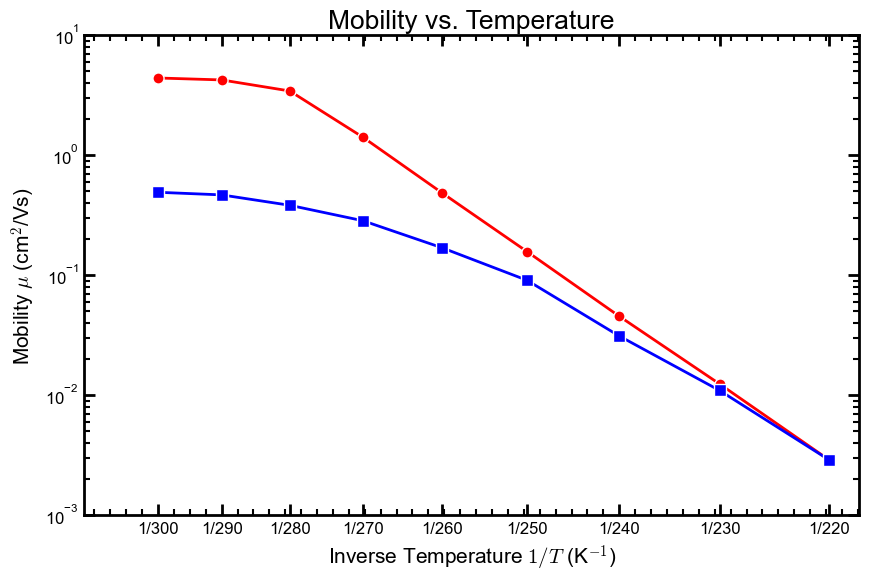

In [36]:
T_1 = [300, 290, 280, 270, 260, 250, 240, 230, 220]
mu_1 = [4.41043105e+00, 4.25030081e+00, 3.43704967e+00, 1.41393914e+00,
                     4.87709092e-01, 1.57709341e-01, 4.55715148e-02, 1.24341987e-02,
                     2.89947352e-03]
V_T_1 = [13.72717472, 14.33181899, 14.53997463, 16.14670001, 20.98733895, 17.8423952,
                           16.2456914, 15.21732862, 14.57374279]

T_2 = [220, 230, 240, 250, 260, 270, 280, 290, 300]

mu_2 = [0.00289947, 0.01097472, 0.03120035, 0.09090993, 0.16989165, 0.28495575, 0.3834718, 0.46810937, 0.49221287]

V_T_2 = [47.38973413, 49.08393775, 47.57033317, 49.53200288, 50.98385218, 54.87899568,
                           56.73067344, 48.74191287, 14.57374279]

inv_T_1 = 1 / np.array(T_1, dtype=float)
inv_T_2 = 1 / np.array(T_2, dtype=float)
inv_T_ticks = 1 / np.array([300, 290, 280, 270, 260, 250, 240, 230, 220], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [300, 290, 280, 270, 260, 250, 240, 230, 220]]

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw = 2, color='red',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw = 2, color='blue',markeredgecolor="white", markeredgewidth=1, markersize=8)
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature', fontsize=19)
plt.savefig('mu-1.eps', format='eps')
plt.show()

Fitted parameters: A = 1.35e+12, Ea = 0.64 eV


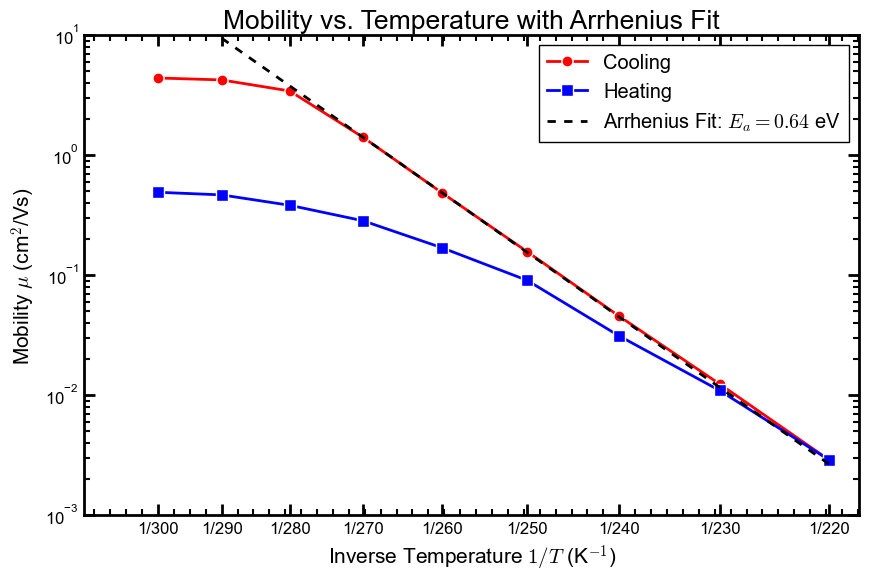

In [37]:
def arrhenius(T, A, Ea):
    k_B = 8.617333262145e-5  # Boltzmann constant in eV/K
    return A * np.exp(-Ea / (k_B * T))

# fit only the last 6 points
T_fit_data = np.array(T_1[-6:], dtype=float)
mu_fit_data = np.array(mu_1[-6:], dtype=float)

popt, pcov = curve_fit(arrhenius, T_fit_data, mu_fit_data, p0=(1e-3, 0.1))
A_fit, Ea_fit = popt
print(f"Fitted parameters: A = {A_fit:.2e}, Ea = {Ea_fit:.2f} eV")

T_fit = np.linspace(220, 290, 100)
mu_fit = arrhenius(T_fit, *popt)

plt.semilogy(inv_T_1, mu_1, marker='o', linestyle='-', lw=2, color='red',
             markeredgecolor="white", markeredgewidth=1, markersize=8, label='Cooling')
plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw=2, color='blue',
             markeredgecolor="white", markeredgewidth=1, markersize=8, label='Heating')
plt.semilogy(1 / T_fit, mu_fit, ls='--', lw = 2, color='black', label=rf'Arrhenius Fit: $E_a = {Ea_fit:.2f}$ eV')
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.title('Mobility vs. Temperature with Arrhenius Fit', fontsize=19)
plt.legend(numpoints=1)
plt.show()